In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# imports
from matplotlib import pyplot as plt
import numpy as np
import sympy as sp
import torch
import os
import arviz as az
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

from equayes import Equayes, PROJECT_ROOT
from equayes.core.pyro_backend import utils as pyro_utils
from equayes.visualisation import predictive_plotting as pred_plot

c:\Users\c.findenig\AppData\Local\anaconda3\envs\pyro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0, 0.5, 'y')

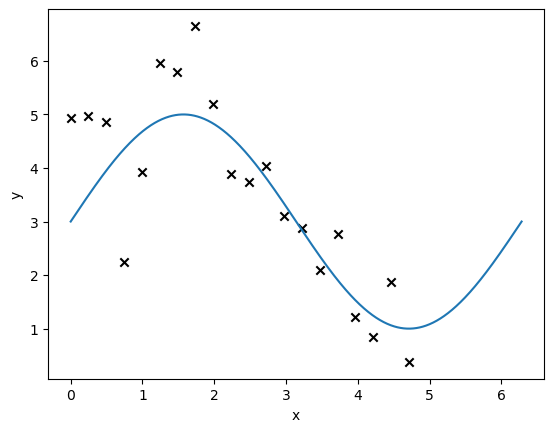

In [3]:
# create data
N_train = 20
N_test = 1000
seed = 42

noise_sigma = 1.  
np.random.seed(seed)
torch.manual_seed(seed)

def synthetic_function_1d(x, noise_sigma=1.):
    y = 2 * torch.sin(x) + 3
    y_obs = y + torch.randn(x.shape if len(x) > 0 else (1,)) * noise_sigma
    return y, y_obs


x_train = torch.linspace(0, 3*np.pi/2, steps=N_train)
x_test = torch.linspace(0, 4*np.pi/2, steps=N_test)

y_train, y_obs_train = synthetic_function_1d(x_train, noise_sigma)
y_test, y_obs_test = synthetic_function_1d(x_test, noise_sigma)

plt.scatter(x_train, y_obs_train, marker="x", color="black")
plt.plot(x_test, y_test, label="True Function")
plt.xlabel("x")
plt.ylabel("y")


In [61]:
# Do post-hoc Inference on the given Sympy equation string.

# define sympy expression
x0 = sp.Symbol('x0')

expr_sp_true = 2. * sp.sin(x0) + 3. # which parameters do you expect to be random variables?
expr_sp_quadratic = 2. * x0**2 - 1.1 * x0 + 5.

print("Ground truth")
print(sp.sympify(expr_sp_true))
print("Quadratic Function")
print(sp.sympify(expr_sp_quadratic))

equayes = Equayes(
    expr=expr_sp_quadratic, # try another equation
    input_symbols=[x0],
    output_dim=1,
    inference_method_name="mcmc",
    kernel_name="nuts",
    # try to explore and vary the additional parameters, too!
)


equayes.fit(x_train.view((-1,1)), y_obs_train.view((-1,1)))


Ground truth
2.0*sin(x0) + 3.0
Quadratic Function
2.0*x0**2 - 1.1*x0 + 5.0


Sample: 100%|██████████| 2000/2000 [04:20,  7.68it/s, step size=1.04e-01, acc. prob=0.930]


In [62]:
equayes.predict(x_train.view((-1,1)), sample_prior=False, parallel=True)["mu"].shape


torch.Size([500, 1, 20, 1])


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
 epsilon[0]      1.06      0.18      1.04      0.76      1.33    399.96      1.01
theta_p0[0]      4.53      0.62      4.52      3.60      5.55    242.13      1.01
theta_p1[0]     -0.34      0.13     -0.34     -0.56     -0.16    197.53      1.02
theta_p2[0]      0.69      0.62      0.70     -0.17      1.78    186.44      1.02

Number of divergences: 0


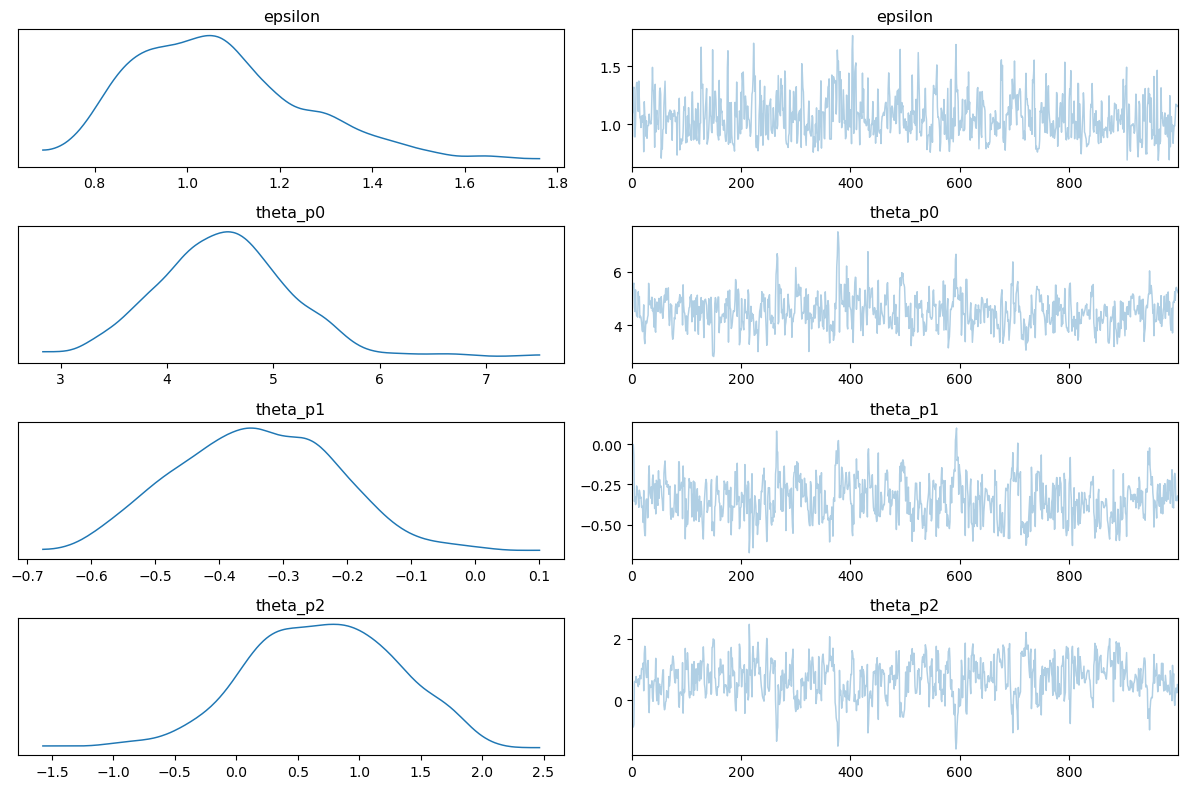

In [63]:
# Evaluation
os.makedirs(f"{PROJECT_ROOT}/output", exist_ok=True)

equayes.inference_diagnostics()

idata = equayes.get_posterior()
if type(idata) is not az.InferenceData:
    idata = pyro_utils.guide_to_inference_data(equayes._pyro_model, equayes._guide, x_train.view((-1,1)), num_samples=3000)

az.plot_trace(idata)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/output/posterior_{equayes.inference_method_name}_{equayes.kernel_name}.png")
# 

In [64]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

torch.Size([500, 1, 1000, 1])


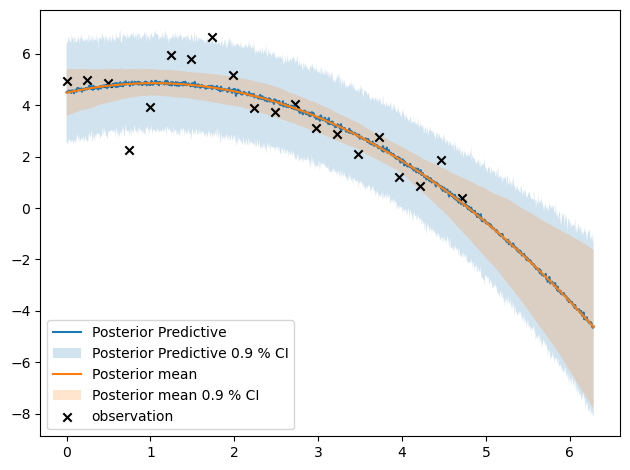

In [65]:
pred_samples = equayes.predict(x_test.view(-1,1), n_predictive_samples=500, parallel=True)
print(pred_samples["mu"].shape)
ax = pred_plot.plot_1d_predictive_density(x_test.numpy(), pred_samples["obs"].squeeze().numpy(), label="Posterior Predictive")
ax = pred_plot.plot_1d_predictive_density(x_test.numpy(), pred_samples["mu"].squeeze().numpy(), label="Posterior mean", ax=ax)

ax.scatter(x_train, y_obs_train, marker="x", color="black", label="observation")

plt.legend()
plt.tight_layout()

plt.savefig(f"{PROJECT_ROOT}/output/post_pred__{equayes.inference_method_name}_{equayes.kernel_name}.png")